# Chapitre 7 — Fine-tuning de GMIC

**🎯 Objectif :** comprendre les **gestes** pour adapter les poids NYU à RSNA — charger (`strict=False`), **geler ou dégeler** le backbone, dompter la BatchNorm, écrire la loss 3 têtes, saturer le GPU — puis **expérimenter** les régimes toi-même.
**⏱ Durée :** démos jouet ~1–2 min sur CPU ; l'entraînement réel (donné en référence) exige un GPU + les données RSNA.

On adapte les poids NYU à RSNA. Il n'y a pas *un* bon réglage : il y a un curseur,
de « on ne touche à rien sauf la tête » à « on ré-entraîne tout ». Ce curseur, c'est
la quantité de paramètres qu'on laisse bouger.

| Régime | On entraîne | Plutôt quand | Risque |
|---|---|---|---|
| Full fine-tuning | tout (~14 M) | beaucoup de données cible | surapprentissage |
| Linear-probe | la tête seule (~0,13 M, < 1 %) | peu de positifs | sous-apprentissage si domaine trop loin |
| Gradual unfreezing | tête, puis backbone par paliers | compromis | plus de réglages |

Un repère utile pour RSNA : il contient **peu de cancers** (~2 %), donc un
full fine-tuning des ~14 M de paramètres a tendance à **surapprendre** vite —
c'est pourquoi le **linear-probe** (geler les deux backbones `ds_net` et `dn_resnet`,
n'entraîner que la tête) est un **bon point de départ**. Mais rien ne t'y oblige :
la démo de gel plus bas expose un simple bouton `FREEZE_BACKBONE` que tu peux passer
à `False` pour tout dégeler et **voir toi-même** le compromis stabilité / plafond.

Ce chapitre enseigne donc les **cinq gestes** (ils servent quel que soit le régime), pas
une recette figée. Les **démos jouet** tournent sur CPU avec `torch` seul ; la
démonstration du gel tourne sur le **vrai modèle GMIC** ; la boucle complète (données
RSNA + GPU) est donnée en référence à la fin.

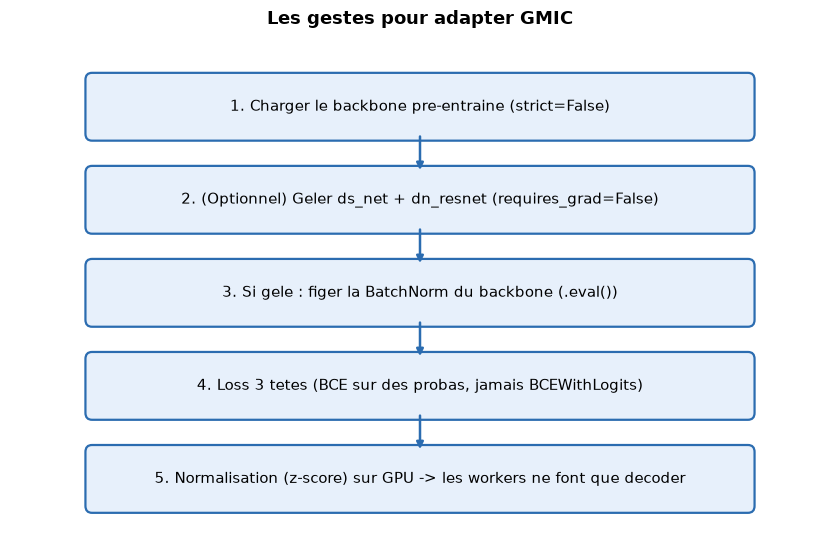

In [1]:
import os, sys
import torch
from course_utils import flowchart, gmic_dir
sys.path.insert(0, gmic_dir())

flowchart([
    '1. Charger le backbone pre-entraine (strict=False)',
    '2. (Optionnel) Geler ds_net + dn_resnet (requires_grad=False)',
    '3. Si gele : figer la BatchNorm du backbone (.eval())',
    '4. Loss 3 tetes (BCE sur des probas, jamais BCEWithLogits)',
    '5. Normalisation (z-score) sur GPU -> les workers ne font que decoder',
], title='Les gestes pour adapter GMIC')

## Geste 1 — Charger les poids (`strict=False`)

`load_state_dict(strict=False)` tolère les **clés manquantes** (paramètre du modèle
absent du checkpoint → garde son init aléatoire, typiquement la tête redimensionnée)
et les **clés en trop** (ignorées). C'est exactement ce qu'on veut : réutiliser le
backbone, réinitialiser la tête. ⚠️ Il ne tolère **pas** les *shapes* incompatibles.

In [2]:
import torch.nn as nn

# Démo jouet : checkpoint sans 'head.weight' -> reste à l'init
ckpt = {'feat.weight': torch.randn(4, 1), 'feat.bias': torch.randn(4), 'head.bias': torch.randn(2)}
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.feat = nn.Linear(1, 4)
        self.head = nn.Linear(4, 2)
    def forward(self, x): return self.head(torch.relu(self.feat(x)))
missing, unexpected = Net().load_state_dict(ckpt, strict=False)
print('manquantes :', missing)      # ['head.weight'] -> init aléatoire
print('en trop    :', unexpected)   # []

manquantes : ['head.weight']
en trop    : []


## Geste 2 — Geler le backbone (le curseur du chapitre)

Les deux gros extracteurs ResNet sont enregistrés sous les préfixes **`ds_net`**
(global) et **`dn_resnet`** (local). Mettre `requires_grad=False` sur ces préfixes :
(1) aucun gradient calculé, (2) exclus de l'optimiseur, (3) moins de mémoire.

C'est ici que se règle le **curseur** de tout à l'heure : `FREEZE_BACKBONE` décide si on gèle
(linear-probe) ou pas (full fine-tuning). Bascule-le et rejoue la cellule d'entraînement pour
comparer les deux régimes.

> Cette cellule **définit** `freeze_backbone` et **compte** ce que le gel changerait — elle ne
> modifie rien. Le gel est appliqué dans la cellule d'entraînement, juste avant la construction
> de l'optimiseur, pour qu'elle se lise seule sans dépendre d'un état posé ici.

In [3]:
from src.modeling.gmic import GMIC
from course_utils import pick_device

DEVICE = pick_device(verbose=False)

# ────────────────────────────────────────────────────────────────────────────
FAST_DEMO = True    # <── True  = résolution RÉDUITE : ~10x plus rapide, pour ITÉRER.
#                          False = la vraie config GMIC (2944x1920), pour un run sérieux.
# ────────────────────────────────────────────────────────────────────────────
# On ne peut PAS juste rétrécir l'image : trois contraintes internes à GMIC lient la
# résolution, cam_size et crop_shape. Les ignorer donne soit un assert, soit — pire — des
# NaN silencieux.
#
#  1. cam_size DOIT valoir (H/64, W/64). Le forward fait `assert h_h == h` : ds_net divise
#     la résolution par 64, donc H et W doivent être des multiples de 64.
#  2. top_t = round(cam_h * cam_w * percent_t) doit rester >= 1. En dessous, le pooling
#     top-t% moyenne un ensemble VIDE -> y_global = NaN, sans aucune erreur. Mesuré : en
#     384x256, cam=(6,4) = 24 cellules -> top_t = 0 -> y_global NaN. C'est pour ça qu'on
#     s'arrête à /4 et pas /8.
#  3. la fenêtre ROI en cellules vaut round(crop_shape/64) : réduire l'image SANS réduire
#     crop_shape ne rend pas la branche locale plus rapide (son coût ne dépend que de
#     crop_shape et de K, pas de la taille de l'image).
if FAST_DEMO:
    DEMO_H, DEMO_W = 704, 448             # /4 -> cam (11,7) = 77 cellules -> top_t = 2 ✔
    CAM_SIZE, CROP_SHAPE = (11, 7), (64, 64)
else:
    DEMO_H, DEMO_W = 2944, 1920           # la vraie taille, celle que produit le ch3
    CAM_SIZE, CROP_SHAPE = (46, 30), (256, 256)

params = {'device_type': 'gpu' if DEVICE.type == 'cuda' else 'cpu', 'gpu_number': 0,
          'cam_size': CAM_SIZE, 'K': 6, 'crop_shape': CROP_SHAPE, 'percent_t': 0.02,
          'use_v1_global': False, 'post_processing_dim': 256, 'num_classes': 2}
model = GMIC(params)
# weights_only=True : vérifié -> ce checkpoint NYU est un simple state_dict de tenseurs
# (torch.load le charge sans exécuter de code arbitraire, la voie sûre par défaut).
ckpt = torch.load(os.path.join(gmic_dir(), 'models', 'sample_model_1.p'),
                  map_location='cpu', weights_only=True)
# cam_size et crop_shape ne changent AUCUNE forme de paramètre (ce sont des réglages
# spatiaux).
missing_g, unexpected_g = model.load_state_dict(ckpt, strict=False)

top_t = int(round(CAM_SIZE[0] * CAM_SIZE[1] * params['percent_t']))
print(f"config : {'RAPIDE' if FAST_DEMO else 'PLEINE RÉSOLUTION'} — entrée {DEMO_H}x{DEMO_W}, "
      f"cam {CAM_SIZE}, crop {CROP_SHAPE}")
print(f"         top_t = {top_t} cellule(s) sur {CAM_SIZE[0]*CAM_SIZE[1]}"
      f"{'  ⚠️ 0 -> y_global serait NaN !' if top_t == 0 else '  ✔'}")
print(f"poids  : {len(missing_g)} clé(s) manquante(s), {len(unexpected_g)} en trop")

# ────────────────────────────────────────────────────────────────────────────
FREEZE_BACKBONE = True    # <── LE CURSEUR : True = linear-probe (tête seule) ;
#                                 False = full fine-tuning (tout bouge). Rejoue la
#                                 cellule d'entraînement après avoir basculé.
# ────────────────────────────────────────────────────────────────────────────

BACKBONE = ('ds_net', 'dn_resnet')

def freeze_backbone(model):
    """requires_grad=False sur les deux backbones. Renvoie le nb de params gelés.

    APPELÉE PAR LA CELLULE D'ENTRAÎNEMENT, pas ici : le gel doit se lire à l'endroit où il
    compte (juste avant la construction de l'optimiseur, qui filtre sur requires_grad).
    """
    n = 0
    for name, p in model.named_parameters():
        if name.startswith(BACKBONE):
            p.requires_grad = False      # ni gradient, ni place dans l'optimiseur
            n += p.numel()
    return n

# DÉMO (sans rien modifier) : ce que le curseur décidera. On compte simplement les params
# par préfixe — le vrai gel est appliqué plus bas, dans la cellule d'entraînement.
bk = sum(p.numel() for n, p in model.named_parameters() if n.startswith(BACKBONE))
tot = sum(p.numel() for p in model.parameters())
print(f'\ncurseur FREEZE_BACKBONE = {FREEZE_BACKBONE}'
      f"  -> {'linear-probe' if FREEZE_BACKBONE else 'full fine-tuning'}")
print(f'  backbone (ds_net + dn_resnet) : {bk/1e6:.2f} M / {tot/1e6:.2f} M params  ({100*bk/tot:.1f} %)')
print(f'  tête                          : {(tot-bk)/1e6:.2f} M params  ({100*(tot-bk)/tot:.1f} %)')
print(f"  -> entraînable une fois le gel appliqué : "
      f"{(tot-bk)/1e6 if FREEZE_BACKBONE else tot/1e6:.2f} M")

config : RAPIDE — entrée 704x448, cam (11, 7), crop (64, 64)
         top_t = 2 cellule(s) sur 77  ✔
poids  : 0 clé(s) manquante(s), 1 en trop

curseur FREEZE_BACKBONE = True  -> linear-probe
  backbone (ds_net + dn_resnet) : 13.98 M / 14.11 M params  (99.0 %)
  tête                          : 0.13 M params  (1.0 %)
  -> entraînable une fois le gel appliqué : 0.13 M


## Geste 3 — Le piège **BatchNorm** (seulement si on gèle)

`requires_grad=False` gèle les **poids**, mais **pas** les statistiques de BatchNorm : en mode
`train()`, `running_mean` / `running_var` continuent de se mettre à jour à chaque batch — le
backbone « gelé » **dériverait quand même**.

La raison est qu'il s'agit de **deux natures d'état différentes**, chacune avec son propre
interrupteur :

| | Nature | Mis à jour par | Gouverné par |
|---|---|---|---|
| `weight`, `bias` | `nn.Parameter` | l'**optimiseur**, via les gradients | `requires_grad` |
| `running_mean`, `running_var` | **buffer** | l'arithmétique du **forward** | mode `train()` / `eval()` |

Les buffers ne reçoivent aucun gradient : `requires_grad` n'a donc **aucune prise** sur eux, et
`.eval()` n'a réciproquement aucune prise sur les poids. Les deux gestes sont indépendants et
tous les deux nécessaires — la démo ci-dessous le montre sur une BatchNorm jouet.

Et comme `model.train()` est **récursif**, il rallume la BN : le geste 3 doit donc être
ré-appliqué **après** chaque `train()`. En full fine-tuning au contraire on *veut* que la BN
s'adapte, et on saute ce geste.

> Comme au geste 2, cette cellule ne fait que **définir** `set_backbone_eval` — l'application
> au vrai modèle est dans la cellule d'entraînement, juste après `model.train()`.

In [4]:
bn = nn.BatchNorm1d(3)
bn.train()
for _ in range(5):
    bn(torch.randn(16, 3) + 10.0)
print('train() -> running_mean dérive :', [round(v, 2) for v in bn.running_mean.tolist()])
bn.eval()
frozen_mean = bn.running_mean.clone()
for _ in range(5):
    bn(torch.randn(16, 3) + 100.0)
print('eval()  -> figée ?', torch.allclose(frozen_mean, bn.running_mean))

# ⚠️ .eval() ne fige QUE les buffers (running_mean/var) : il ne touche PAS requires_grad,
# donc il n'empêche pas l'optimiseur de modifier les poids. Les deux gestes sont
# indépendants et tous les deux nécessaires — voir la démo ci-dessous.
for p in bn.parameters():
    p.requires_grad = False
print('les 2 gestes -> poids gelés :', not any(p.requires_grad for p in bn.parameters()),
      '| buffers gelés :', not bn.training)

def set_backbone_eval(model):
    """Met les modules du backbone en .eval() -> ses buffers BN arrêtent de bouger.

    APPELÉE PAR LA CELLULE D'ENTRAÎNEMENT, pas ici, et toujours APRÈS model.train() :
    train() est récursif et rallumerait la BN.
    """
    for name, module in model.named_modules():
        if name.startswith(BACKBONE):
            module.eval()

train() -> running_mean dérive : [4.08, 4.2, 4.16]
eval()  -> figée ? True
les 2 gestes -> poids gelés : True | buffers gelés : True


## Geste 4 — La loss 3 têtes (et le piège `BCEWithLogits`)

La loss du papier supervise les **trois** sorties + régularise la saillance :

$$\mathcal{L} = \mathrm{BCE}(y_{fusion}) + \mathrm{BCE}(y_{global}) + \mathrm{BCE}(y_{local}) + \beta\,\lVert \mathrm{saliency}\rVert_1$$

Les sorties GMIC sont **déjà des probabilités** (sigmoïde/agrégation bornée). On
utilise donc `binary_cross_entropy`, **jamais** `BCEWithLogits` qui ré-appliquerait
une sigmoïde (double sigmoïde → gradients écrasés → collapse).

In [5]:
import torch.nn.functional as F
proba = torch.tensor([0.99, 0.01])     # DÉJÀ une proba
target = torch.tensor([1.0, 0.0])
good = F.binary_cross_entropy(proba.clamp(1e-7, 1 - 1e-7), target)
bad = F.binary_cross_entropy_with_logits(proba, target)
print(f'BCE(proba)        = {good.item():.4f}  (correct : prédiction sûre et juste)')
print(f'BCEWithLogits     = {bad.item():.4f}  (FAUX : retraite 0.99 en sigmoid(0.99)=0.73)')

BCE(proba)        = 0.0101  (correct : prédiction sûre et juste)
BCEWithLogits     = 0.5071  (FAUX : retraite 0.99 en sigmoid(0.99)=0.73)


## Geste 5 — Saturer le GPU : la normalisation quitte le CPU

GMIC s'entraîne en **pleine résolution 2944×1920**. Sur une VM au GPU puissant mais à seulement **8 vCPU**, le poste coûteux est le **décodage des PNG** côté CPU. Si les workers du `DataLoader` doivent EN PLUS normaliser (z-score) les images, ils ne suivent pas → le GPU attend et plafonne à ~**49 %** : *CPU/IO-bound*, pas *GPU-bound*.

La parade : les workers CPU ne font plus que **décoder** ; la **normalisation z-score** est appliquée au **batch entier sur le GPU**, juste après le transfert. Résultat mesuré sur nos runs : utilisation GPU **49 % → 91 %**.

**Pourquoi le z-score, et pas le reste du prétraitement ?** Parce que c'est la seule étape que le ch3 n'a pas pu figer sur disque : centrer-réduire produit des valeurs négatives, impossibles à stocker dans un PNG uint8. Crop, resize et flip sont faits **une fois pour toutes** — les déporter sur GPU n'aurait aucun sens. Seul ce qui est **recalculé à chaque chargement** vaut la peine d'être déplacé.

Le **chapitre 5** (`05_bench_normalisation.ipynb`) mesure ce principe à 512×512 : à cette résolution le CPU suit encore souvent le GPU, et le gain est parfois marginal, voire négatif sur petit batch. Ici, en 2944×1920 (~22× plus de pixels par image), le décodage + la normalisation CPU deviennent le vrai goulot — d'où un gain net, alors qu'il restait incertain en 512×512.

`gpu_standardize` ci-dessous est la fonction réelle. C'est elle qu'on retrouvera dans la cellule d'entraînement.

In [6]:
import torch

def gpu_standardize(x):
    """z-score par image, sur GPU (la normalisation quitte aussi le CPU).

    dim=(1,2,3) = canal+hauteur+largeur, mais PAS la dimension 0 (le batch) : chaque image
    garde donc sa propre moyenne/écart-type, comme le faisait le z-score CPU image par image.
    """
    x = x.float()
    m = x.mean(dim=(1, 2, 3), keepdim=True)
    # unbiased=False = écart-type "population" (÷N, pas ÷N-1) : la convention numpy
    # utilisée par le pipeline CPU d'origine -> vérifié numériquement équivalent.
    s = x.std(dim=(1, 2, 3), keepdim=True, unbiased=False).clamp(min=1e-5)
    return (x - m) / s

# Batch jouet à la résolution RÉELLE de la config courante (DEMO_H x DEMO_W du geste 2) :
# le code est le même quelle que soit la taille, mais autant que la démo montre ce que le
# modèle va vraiment recevoir plus bas.
batch = torch.rand(2, 1, DEMO_H, DEMO_W, device=DEVICE)
out = gpu_standardize(batch)
print('device:', DEVICE, '| batch', tuple(batch.shape), '-> standardisé', tuple(out.shape))
print(f'après z-score : moyenne ≈ {out.mean().item():.1e}, écart-type ≈ {out.std().item():.2f}')

device: cuda | batch (2, 1, 704, 448) -> standardisé (2, 1, 704, 448)
après z-score : moyenne ≈ -5.4e-08, écart-type ≈ 1.00


## Les cinq gestes réunis — un vrai mini-entraînement

Les cellules ci-dessus ont **montré** chaque geste isolément, sur des démos jouet. Aucune n'a
touché au modèle : la cellule suivante applique elle-même les cinq gestes, sur **toutes** les
images prétraitées au ch3, via un `DataLoader` qui itère en batches successifs.

**L'ordre n'est pas décoratif** — deux contraintes le fixent :

| # | Geste | Où | Pourquoi cette place |
|---|---|---|---|
| 1 | `freeze_backbone(model)` | avant la boucle | **avant** l'optimiseur, qui filtre sur `requires_grad` |
| 2 | `Adam([p for p in ... if p.requires_grad])` | avant la boucle | ne reçoit donc jamais les paramètres gelés |
| 3 | `model.train()` | **chaque epoch** | met tout le modèle en mode entraînement… |
| 4 | `set_backbone_eval(model)` | **chaque epoch** | …donc juste **après**, sinon `train()` rallume la BN |
| 5 | `gpu_standardize(x)` | chaque batch | z-score sur GPU, les workers ne font que décoder |

C'est ici que le geste 3 prend tout son sens : `model.train()` est appelé **à chaque epoch**,
donc `set_backbone_eval` doit repasser derrière **à chaque fois**. Inverser 1 et 2 donnerait un
optimiseur tenant les 14 M de paramètres ; oublier le rappel de 4 laisserait la BatchNorm du
backbone dériver. Dans les deux cas **aucune erreur** ne serait levée — d'où les contrôles
affichés (paramètres réellement confiés à l'optimiseur, BN en mode train, et un poids du
backbone comparé avant/après).

**Le sampler équilibré.** L'échantillon ne contient qu'une poignée de seins malins. Sans
rééquilibrage, presque tous les batches seraient 100 % négatifs et le réseau apprendrait
simplement à répondre « non » — le collapse du ch4. Un `WeightedRandomSampler` ramène le tirage
à ~50/50. Avec si peu de positifs, cela **sur-échantillonne les mêmes images** : ça donne un
signal d'apprentissage, pas une généralisation.

**Une astuce d'implémentation.** `GMIC.forward` ne *renvoie* que `y_fusion`, mais il **stocke**
`y_global`, `y_local` et `saliency_map` en attributs du modèle, **sans les détacher du graphe**.
On reconstruit donc la loss 3 têtes en lisant ces attributs après le forward.

**Batch et mémoire.** `BATCH = 4` a été mesuré sur une Quadro P1000 (4,3 Go) : **0,18 Go** en
mode rapide, **1,03 Go** en pleine résolution — il tient donc dans les deux modes, et basculer
`FAST_DEMO` ne provoquera pas d'OOM. Monte-le si ton GPU a de la marge (le pic réel est affiché
en fin de cellule).

> La cellule se désactive proprement s'il manque les données ou le GPU, et attrape l'OOM.
> Quelques epochs sur si peu d'images n'apprennent rien : on vérifie que **la mécanique
> tourne** — loss finie, gradients non nuls sur la tête, backbone immobile.

In [7]:
import glob, pickle, time
import numpy as np, cv2
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from course_utils import (preprocess_dir, dataloader_kwargs, save_run, list_runs,
                          course_root, auc_score)

# ────────────────────────────────────────────────────────────────────────────
DATASET  = 'rsna_sample'  # <── LE MÊME curseur qu'aux ch3/ch4/ch5 (course_utils.preprocess_dir)
BATCH    = 4              # <── mesuré sur Quadro P1000 (4,3 Go) : 0,18 Go en mode rapide et
#                                1,03 Go en pleine résolution -> tient dans les DEUX modes.
N_EPOCHS = 20             # <── on itère sur TOUTES les images, N_EPOCHS fois
# ────────────────────────────────────────────────────────────────────────────
IMG_DIR  = preprocess_dir(DATASET, 'cropped_images')
PKL_PATH = preprocess_dir(DATASET, 'data.pkl')
EPS, BETA = 1e-7, 2e-4

def bce(prob, target):
    """BCE sur des probas DÉJÀ sigmoïdées (geste 4). Le clamp évite log(0) = -inf."""
    return F.binary_cross_entropy(prob.float().clamp(EPS, 1 - EPS), target)

def three_head_loss(model, target, beta=BETA):
    """La loss du papier, lue sur les ATTRIBUTS que le forward vient de poser.

    y_fusion / y_global / y_local ne sont PAS détachés dans GMIC.forward -> ils portent le
    gradient, donc backward() remonte dans les trois branches. Le terme L1 sur la saillance
    la pousse à rester parcimonieuse (sans lui, une carte allumée partout garderait un bon
    score top-t % tout en ne désignant plus rien : l'interprétabilité serait perdue).
    """
    return (bce(model.y_fusion, target) + bce(model.y_global, target)
            + bce(model.y_local, target) + beta * model.saliency_map.float().abs().mean())

def labels_from_pkl(pkl_path, img_dir):
    """Table `chemin du PNG` -> [benign, malignant] du SEIN de cette vue.

    Ne recalcule RIEN : le ch3 (build_exam_pkl) a déjà écrit ces labels dans data.pkl. On les
    RESTRUCTURE seulement, car data.pkl est organisé par EXAMEN (1 dict par patient, 4 listes
    de vues, 1 seul cancer_label partagé) alors qu'ici on parcourt des fichiers un par un.
    On indexe donc par le CHEMIN que `glob` renverra : le label se lit ensuite en O(1), sans
    traduction intermédiaire.

    num_classes=2 = deux sigmoïdes INDÉPENDANTES : un sein peut être les deux, ou aucun.
    """
    with open(pkl_path, 'rb') as f:
        exams = pickle.load(f)
    out = {}
    for e in exams:                                       # un e = un patient
        for view in ('L-CC', 'L-MLO', 'R-CC', 'R-MLO'):
            side = 'left' if view.startswith('L') else 'right'
            for sfp in e.get(view, []):                   # sfp = '<pid>/<iid>'
                out[os.path.join(img_dir, sfp + '.png')] = [
                    float(e['cancer_label'][f'{side}_benign']),
                    float(e['cancer_label'][f'{side}_malignant'])]
    return out

class MammoDataset(Dataset):
    """Un PNG prétraité (ch3) -> (image BRUTE, label). Les workers ne font QUE décoder.

    Aucune normalisation ici : c'est tout l'intérêt du geste 5. Le z-score est appliqué au
    batch entier sur GPU dans la boucle — les workers CPU restent libres pour décoder.
    """
    def __init__(self, paths, lab):
        self.paths, self.lab = paths, lab

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        p = self.paths[i]
        img = cv2.imread(p, cv2.IMREAD_UNCHANGED).astype(np.float32)
        if img.shape[:2] != (DEMO_H, DEMO_W):
            # INTER_AREA : on RÉDUIT (moyenne des pixels), évite l'aliasing — cf. ch3 étape 4.
            img = cv2.resize(img, (DEMO_W, DEMO_H), interpolation=cv2.INTER_AREA)
        # [None] ajoute l'axe CANAL : (H, W) -> (1, H, W). Le DataLoader empilera les N
        # échantillons en (N, 1, H, W) tout seul.
        return torch.from_numpy(img)[None], torch.tensor(self.lab[p])

_paths = sorted(glob.glob(os.path.join(IMG_DIR, '**', '*.png'), recursive=True))

if not _paths or not os.path.isfile(PKL_PATH):
    print(f'Entraînement SAUTÉ : il manque les images ou data.pkl dans {IMG_DIR}')
    print(f'  -> exécute le ch1 (download) puis le ch3 (preprocessing) avec DATASET={DATASET!r}.')
elif DEVICE.type != 'cuda':
    print('Entraînement SAUTÉ : aucun GPU CUDA. GMIC est inutilisable sur CPU même en réduit')
    print('  (les gestes 1 à 4 ci-dessus, eux, ont bien tourné sur CPU).')
else:
    lab = labels_from_pkl(PKL_PATH, IMG_DIR)
    # data.pkl ne référence que les vues effectivement prétraitées : on ne garde que les
    # images dont on connaît le label.
    usable = [p for p in _paths if p in lab]
    assert usable, 'aucune image du dossier ne figure dans data.pkl (prétraitement incohérent ?)'
    is_mal = np.array([lab[p][1] for p in usable])        # 1.0 = sein avec cancer biopsié
    n_mal = int(is_mal.sum())

    # ── Sampler ÉQUILIBRÉ. Sans lui, avec si peu de positifs, presque tous les batches
    #    seraient 100 % négatifs : la loss n'aurait rien à discriminer et le réseau
    #    apprendrait juste « réponds non » (le collapse du ch4). Poids = 1/effectif de la
    #    classe -> chaque tirage est ~50/50. Avec 2 positifs seulement, cela sur-échantillonne
    #    les mêmes 2 images : ça donne un signal, pas une généralisation.
    if 0 < n_mal < len(usable):
        w = np.where(is_mal == 1, 1 / n_mal, 1 / (len(usable) - n_mal))
        sampler = WeightedRandomSampler(torch.tensor(w, dtype=torch.double), len(usable),
                                        replacement=True)
        dl_kw = dataloader_kwargs(batch_size=BATCH, sampler=sampler)
    else:
        # Aucun positif (ou que des positifs) : rien à équilibrer, on mélange simplement.
        sampler, dl_kw = None, dataloader_kwargs(batch_size=BATCH, shuffle=True)

    loader = DataLoader(MammoDataset(usable, lab), **dl_kw)
    print(f'{len(usable)} images utilisables ({n_mal} malignes) | batch {BATCH} '
          f'-> {len(loader)} batches/epoch | workers {dl_kw["num_workers"]}'
          f"{' | sampler équilibré' if sampler is not None else ' | shuffle'}")

    model = model.to(DEVICE)

    # ── GESTE 2 : geler le backbone. AVANT l'optimiseur, qui filtre sur requires_grad.
    frozen = freeze_backbone(model) if FREEZE_BACKBONE else 0
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad],
                                 lr=1e-4, weight_decay=1e-5)
    n_opt = sum(p.numel() for g in optimizer.param_groups for p in g['params'])
    print(f'geste 2 — gelé {frozen/1e6:.2f} M | optimiseur : {n_opt/1e6:.2f} M params '
          f'({100*n_opt/sum(p.numel() for p in model.parameters()):.1f} %)')

    # Témoin : copie d'un poids du backbone, pour VÉRIFIER à la fin qu'il n'a pas bougé.
    w_bk = next(p for n, p in model.named_parameters() if n.startswith(BACKBONE)).detach().clone()

    try:
        torch.cuda.reset_peak_memory_stats()
        n_timed, t0, history = 0, None, []
        for epoch in range(N_EPOCHS):
            # ── GESTE 3 : train() PUIS re-figer la BN. C'est ICI que le rappel prend tout
            #    son sens : train() est appelé à CHAQUE epoch et rallume la BatchNorm, donc
            #    set_backbone_eval doit repasser derrière à chaque fois.
            model.train()
            if FREEZE_BACKBONE:
                set_backbone_eval(model)

            tot_loss, ep_p, ep_y = 0.0, [], []
            for x, y in loader:
                x = x.to(DEVICE, non_blocking=True)       # images BRUTES (workers = décodage)
                x = gpu_standardize(x)                     # geste 5 : z-score sur GPU
                y = y.to(DEVICE)
                optimizer.zero_grad()
                model(x)                       # pose y_fusion/y_global/y_local/saliency_map
                loss = three_head_loss(model, y)           # geste 4
                loss.backward()
                optimizer.step()
                tot_loss += loss.item()
                # Proba malignant (dernier canal) + label, accumulés sur toute l'epoch pour
                # en tirer l'AUC. On lit y_fusion, la SORTIE du modèle (y_global/y_local ne
                # servent qu'à la loss). detach() : on ne veut qu'une mesure, pas de gradient.
                ep_p += model.y_fusion.detach()[:, -1].float().cpu().tolist()
                ep_y += y[:, -1].cpu().tolist()
                if t0 is None:                 # 1er pas hors chrono : il paie l'init CUDA
                    torch.cuda.synchronize(); t0 = time.time()
                else:
                    n_timed += 1
            # AUC sur les images VUES pendant l'epoch : elle dit si le modèle sépare les
            # deux classes, ce que la loss seule ne montre pas. None si l'epoch n'a tiré
            # qu'une seule classe (possible avec si peu de positifs).
            auc = auc_score(ep_y, ep_p)
            history.append({'epoch': epoch + 1, 'loss': tot_loss / len(loader), 'auc': auc})
            print(f'  epoch {epoch+1}/{N_EPOCHS} | loss moyenne {tot_loss/len(loader):.4f} '
                  f"| AUC {'indéfinie' if auc is None else format(auc, '.3f')}")
        torch.cuda.synchronize()
        dt = (time.time() - t0) / max(n_timed, 1)

        w_bk_now = next(p for n, p in model.named_parameters() if n.startswith(BACKBONE))
        print(f'\nbackbone inchangé après {n_timed + 1} pas : {torch.equal(w_bk, w_bk_now)}')
        print(f'✅ {N_EPOCHS} epochs × {len(loader)} batches sur {len(usable)} images '
              f'{DEMO_H}x{DEMO_W} — {dt*1000:.0f} ms/pas, pic mémoire '
              f'{torch.cuda.max_memory_allocated()/1e9:.2f} Go / '
              f'{torch.cuda.get_device_properties(0).total_memory/1e9:.2f} Go.')
        print(f"   Mode {'RAPIDE' if FAST_DEMO else 'PLEINE RÉSOLUTION'} : passe FAST_DEMO="
              f"{not FAST_DEMO} (geste 2) pour "
              f"{'la vraie taille' if FAST_DEMO else 'itérer ~10x plus vite'}.")
        print(f'   ⚠️ {len(usable)} images dont {n_mal} malignes : on valide la MÉCANIQUE '
              f'(loss finie, gradients, backbone figé),\n      pas la performance. '
              f"Un vrai run demande DATASET='rsna' et bien plus d'epochs.")

        # ── Archiver le bilan. Un run GPU sérieux (DATASET='rsna', pleine résolution) ne se
        #    relance pas pour rien : on en garde la trace À CÔTÉ du cours, comme les résultats
        #    de la VM déjà dans data_samples/. save_run() horodate -> les runs s'accumulent,
        #    et remplit seul l'environnement, les comptes de paramètres et le pic mémoire.
        out = save_run(
            'ch7',
            config={'dataset': DATASET, 'resolution': [DEMO_H, DEMO_W], 'fast_demo': FAST_DEMO,
                    'cam_size': list(CAM_SIZE), 'crop_shape': list(CROP_SHAPE),
                    'K': params['K'], 'percent_t': params['percent_t'], 'batch': BATCH,
                    'epochs': N_EPOCHS, 'lr': 1e-4, 'weight_decay': 1e-5, 'beta_l1': BETA,
                    'freeze_backbone': FREEZE_BACKBONE,
                    'sampler': 'weighted' if sampler is not None else 'shuffle'},
            history=history,
            model=model,
            run_kind='gmic_finetune_ch7',
            data={'n_images': len(usable), 'n_malignant': n_mal,
                  'batches_per_epoch': len(loader)},
            ms_per_step=dt * 1000,
            backbone_unchanged=bool(torch.equal(w_bk, w_bk_now)),
        )
        print(f"\n💾 run archivé : {os.path.relpath(out, course_root())}"
              f"  ({len(list_runs('ch7'))} run(s) conservé(s))")

    except RuntimeError as e:
        if 'out of memory' in str(e).lower():
            torch.cuda.empty_cache()
            print(f'OOM avec BATCH={BATCH} : baisse-le, ou mets FAST_DEMO=True. '
                  f'Rien n a été appris.')
        else:
            raise

23 images utilisables (2 malignes) | batch 4 -> 6 batches/epoch | workers 4 | sampler équilibré
geste 2 — gelé 13.98 M | optimiseur : 0.13 M params (1.0 %)
  epoch 1/20 | loss moyenne 4.3597 | AUC 0.085
  epoch 2/20 | loss moyenne 3.6379 | AUC 0.076
  epoch 3/20 | loss moyenne 4.0379 | AUC 0.143
  epoch 4/20 | loss moyenne 3.3138 | AUC 0.212
  epoch 5/20 | loss moyenne 2.2815 | AUC 0.341
  epoch 6/20 | loss moyenne 2.4940 | AUC 0.083
  epoch 7/20 | loss moyenne 2.4953 | AUC 0.092
  epoch 8/20 | loss moyenne 1.9810 | AUC 0.205
  epoch 9/20 | loss moyenne 2.0743 | AUC 0.233
  epoch 10/20 | loss moyenne 2.6022 | AUC 0.364
  epoch 11/20 | loss moyenne 3.1413 | AUC 0.190
  epoch 12/20 | loss moyenne 2.2169 | AUC 0.262
  epoch 13/20 | loss moyenne 2.5494 | AUC 0.288
  epoch 14/20 | loss moyenne 1.9582 | AUC 0.389
  epoch 15/20 | loss moyenne 1.8813 | AUC 0.383
  epoch 16/20 | loss moyenne 2.3444 | AUC 0.300
  epoch 17/20 | loss moyenne 1.7862 | AUC 0.223
  epoch 18/20 | loss moyenne 2.0437 |